In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import pandas as pd



Instructions for updating:
non-resource variables are not supported in the long term


Auto Encoder

아주 간단하면서 강력한 비지도 학습 딥러닝 모델로 입력값을 압축시킨 후, 압축된 정보를 복원해서 입력값과 동일한 출력값을 가지도록 하는 학습 모델이다.

<img src="./autoencoder.png" wigth="1000" align="left" />

학습 과정을 통해 최대한 입력값과 출력값이 일치하도록 모델의 파라미터가 최적화되고 오토 인코딩의 압축된 정보는 입력값에서 노이즈가 제거된 핵심 특징들로 구성된 저차원 데이터로 간주되어 차원 축소 목적으로 오토 인코더가 많이 사용된다.

오토 인코더는 크게 인코더와 디코더로 구분되어 있고, 인코더와 디코더 사이에 압축된 정보가 존재한다.  
인코더와 디코더는 덴즈 레이어로 구성되어 있고, 인코더와 디코더 사이에는 입력되는 원본값 보다 작은 차원을 가지는 덴즈 레이어를 두어 정보를 압축한다.

MNIST 손글씨 데이터를 오토 인코더를 사용해서 차원 축소 후 시각화 한다.

MNIST 손글씨 데이터를 획득한다.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


데이터 전처리

획득된 학습 데이터는 오토 인코더 학습에 사용하고 테스트 데이터 중에서 500개의 데이터만 선택해서 시각화에 사용한다.

In [3]:
x_train = x_train.reshape(60000, 784) # 학습 데이터

# 테스트 데이터 중에서 500개의 데이터만 선택한다.
x_test = x_test[:500]
x_test = x_test.reshape(500, 784) # 테스트 데이터 => 시각화에 사용한다.
y_test = y_test[:500]

# 정규화
x_train = x_train.astype('float32')
x_train /= 255
x_test = x_test.astype('float32')
x_test /= 255

오토 인코더 모델을 만든다.

In [4]:
# 오토 인코더의 입력으로 사용할 placeholder
inputs = tf.placeholder(dtype=tf.float32, shape=[None, 784])
# 입력 데이터를 받아 차원을 128개로 줄이면서 특징을 추출하는 인코더를 만든다.
# tf.nn.tanh: 활성화 함수로 쌍곡선 탄젠트(Hyperbolic Tangent)를 사용한다. 출력값의 범위를 -1과 1사이로 압축해서 비선형성을 유지한다.
encoder = tf.layers.dense(inputs, 128, tf.nn.tanh)
# 128개의 인코더 출력값을 받아 데이터의 핵심 정보만을 남기고 3차원으로 압축한다. 차원 축소
bottleneck = tf.layers.dense(encoder, 3)
# 3차원으로 압축된 공간의 데이터를 다시 원래 차원으로 돌리는 디코드를 만든다.
decoder = tf.layers.dense(bottleneck, 128, tf.nn.tanh)
# 128차원의 디코더 출력값을 받아서 최종적으로 원본 데이터와 같은 크기(784 차원)로 복원하는 출력층을 만든다.
outputs = tf.layers.dense(decoder, 784, tf.nn.sigmoid)

손실 함수와 Adam 옵티마이저

In [5]:
# 모델이 복원한 결과(outputs)와 원본 데이터(inputs) 간의 오차를 평균 제곱 오차 방식으로 계산한다.
loss = tf.losses.mean_squared_error(labels=inputs, predictions=outputs) # 손실 함수
# 계산된 오차를 줄이기 위해 Adam 옵티마이저를 사용하여 모델의 가중치와 바이어스를 업데이트(역전파) 한다.
train = tf.train.AdamOptimizer(0.01).minimize(loss) # 옵티마이저

학습 시킨다.

In [6]:
batch_size = 5000
iteration = len(x_train) // batch_size

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    # 학습 시작
    for epoch in range(50):
        avg_loss = 0.0
        start = 0
        end = batch_size
        # 미니 배치
        for i in range(iteration):
            _, _loss = sess.run([train, loss], feed_dict={inputs: x_train[start:end]})
            start += batch_size
            end += batch_size
            avg_loss += _loss / iteration
        # ===== for i => 미니 배치 종료
        print('epoch: {:2d}, loss: {:7.5f}'.format(epoch + 1, avg_loss))
    # ===== for epoch => 학습 종료
    
    # 학습이 완료되면 오토 인코더를 사용해서 테스트 데이터가 3차원으로 압축된 벡터를 시각화를 하기위해 저장한다.
    _bottleneck = sess.run(bottleneck, feed_dict={inputs: x_test})

epoch:  1, loss: 0.09700
epoch:  2, loss: 0.06713
epoch:  3, loss: 0.06282
epoch:  4, loss: 0.05853
epoch:  5, loss: 0.05701
epoch:  6, loss: 0.05608
epoch:  7, loss: 0.05534
epoch:  8, loss: 0.05454
epoch:  9, loss: 0.05368
epoch: 10, loss: 0.05287
epoch: 11, loss: 0.05224
epoch: 12, loss: 0.05170
epoch: 13, loss: 0.05121
epoch: 14, loss: 0.05070
epoch: 15, loss: 0.05017
epoch: 16, loss: 0.04961
epoch: 17, loss: 0.04901
epoch: 18, loss: 0.04842
epoch: 19, loss: 0.04788
epoch: 20, loss: 0.04741
epoch: 21, loss: 0.04699
epoch: 22, loss: 0.04663
epoch: 23, loss: 0.04631
epoch: 24, loss: 0.04601
epoch: 25, loss: 0.04572
epoch: 26, loss: 0.04545
epoch: 27, loss: 0.04519
epoch: 28, loss: 0.04493
epoch: 29, loss: 0.04469
epoch: 30, loss: 0.04446
epoch: 31, loss: 0.04425
epoch: 32, loss: 0.04404
epoch: 33, loss: 0.04384
epoch: 34, loss: 0.04369
epoch: 35, loss: 0.04354
epoch: 36, loss: 0.04328
epoch: 37, loss: 0.04314
epoch: 38, loss: 0.04302
epoch: 39, loss: 0.04288
epoch: 40, loss: 0.04259


In [10]:
print(len(_bottleneck))
print(type(_bottleneck))
print(_bottleneck)

500
<class 'numpy.ndarray'>
[[-11.490662    -0.14606804  -9.468777  ]
 [  8.204746    -4.2495203  -12.012245  ]
 [  1.5136608    4.7873263  -14.435048  ]
 ...
 [ -6.3872337    0.2633206  -13.824468  ]
 [ -1.0981487   -7.647005   -15.7322035 ]
 [ -5.1765428   -5.7742023  -15.736742  ]]


압축된 데이터를 3차원으로 시각화 한다.

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

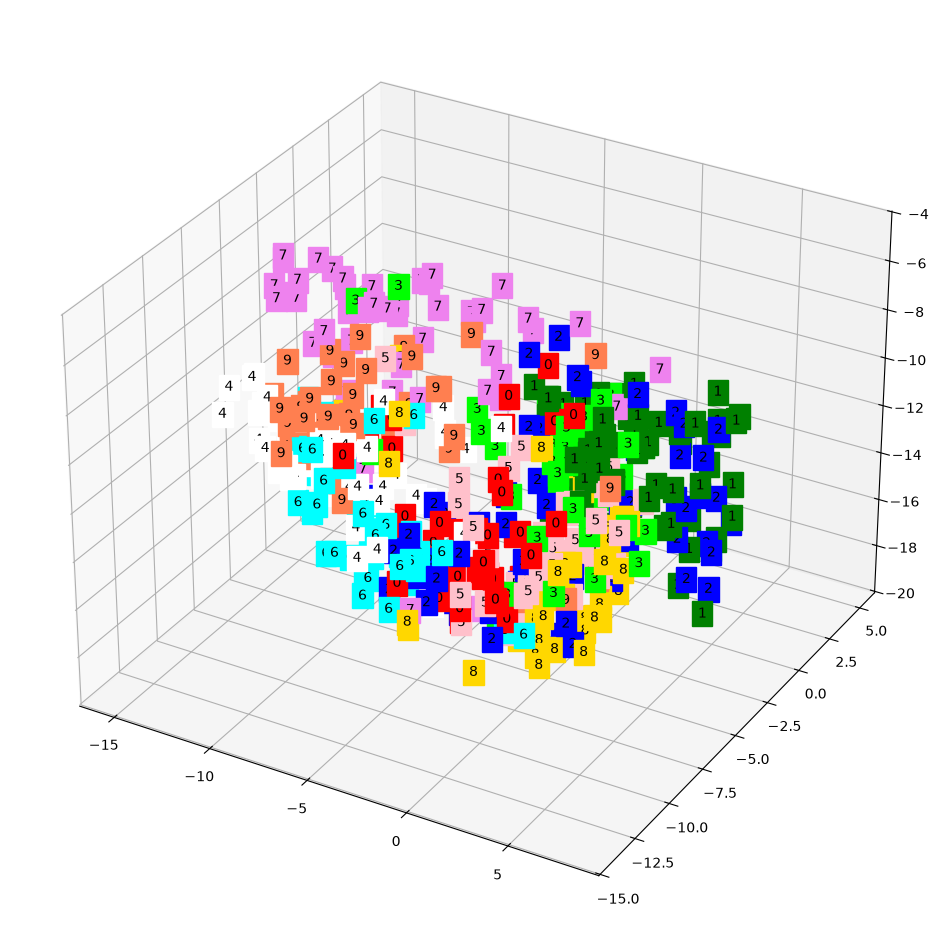

In [18]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(projection='3d')

xs = _bottleneck[:, 0]
ys = _bottleneck[:, 1]
zs = _bottleneck[:, 2]

color = ['red', 'green', 'blue', 'lime', 'white', 'pink', 'aqua', 'violet', 'gold', 'coral']

for x, y, z, label in zip(xs, ys, zs, y_test):
    c = color[int(label)]
    ax.text(x, y, z, str(label), backgroundcolor = c)

ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())
ax.set_zlim(zs.min(), zs.max())
    
plt.show()